# Feed-Forward Neural Network (Binary Readmission)

Predicts hospital **readmission** from the cleaned dataset using the same **binary** target as our KNN and logistic regression models:

- **Not Readmitted (0)** = `NO`
- **Readmitted (1)** = `<30` or `>30`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    learning_curve,
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
)

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

## 1. Load Cleaned Dataset

In [2]:
DATA_PATH = "diabetes+130-us+hospitals+for+years+1999-2008/diabetic_data_cleaned.csv"

df = pd.read_csv(DATA_PATH)
print(f"Shape (raw cleaned file): {df.shape}")

# Align with KNN / logistic regression preprocessing
DROP_HIGH_MISSING = ["weight", "payer_code", "medical_specialty", "max_glu_serum", "A1Cresult"]
ID_COLS = ["encounter_id", "patient_nbr"]
DROP_DIAG = ["diag_1", "diag_2", "diag_3"]

df = df.drop(columns=[c for c in DROP_HIGH_MISSING if c in df.columns], errors="ignore")
df = df.drop(columns=[c for c in ID_COLS if c in df.columns], errors="ignore")
df = df.drop(columns=[c for c in DROP_DIAG if c in df.columns], errors="ignore")

print(f"Shape (after drops): {df.shape}")

Shape (raw cleaned file): (101766, 45)
Shape (after drops): (101766, 40)


## 2. Target Variable (Binary)

To match our KNN and logistic regression setup, we convert the original 3-class `readmitted` labels into a **binary** target:

- `0` = `NO` (Not Readmitted)
- `1` = `<30` or `>30` (Readmitted)

In [3]:
TARGET = "readmitted"

# Binary target: Not Readmitted (0) vs Readmitted (1 = <30 or >30)
y = (df[TARGET] != "NO").astype(int)

# Drop target from features
X = df.drop(columns=[TARGET])

print("Binary target distribution:")
print(y.value_counts().rename({0: "Not Readmitted (0)", 1: "Readmitted (1)"}))

Binary target distribution:
readmitted
Not Readmitted (0)    54864
Readmitted (1)        46902
Name: count, dtype: int64


## 3. Feature Types

In [4]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"Numeric  ({len(numeric_features)}):     {numeric_features}")
print()
print(f"Categorical ({len(categorical_features)}): {categorical_features}")

Numeric  (11):     ['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

Categorical (28): ['race', 'gender', 'age', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']


## 4. Preprocessing Pipeline

In [5]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline,     numeric_features),
    ("cat", categorical_pipeline, categorical_features)
], remainder="drop")

## 5. Train / Validation / Test Split

In [6]:
# 60/20/20 split (Train / Validation / Test) — stratified by binary target
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

# 0.25 of the remaining 80% = 20% of total
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print(f"Train: {X_train.shape[0]:,}  |  Val: {X_val.shape[0]:,}  |  Test: {X_test.shape[0]:,}")

Train: 61,059  |  Val: 20,353  |  Test: 20,354


## 6. Define the Neural Network Search Space

We use `MLPClassifier` (ReLU + Adam) and tune the architecture and training hyperparameters on the validation set.

In [7]:
# Base model settings (specific hyperparameters are tuned in the next section).
mlp = MLPClassifier(
    activation="relu",
    solver="adam",
    alpha=1e-4,
    early_stopping=False,
    random_state=RANDOM_STATE,
    verbose=False,
)

## 7. Hyperparameter Tuning + Final Fit

To align with our other classifiers, we tune hyperparameters using the **validation set** (selection criterion: **validation accuracy**), then refit the best model and evaluate once on the **test set**.

In [8]:
from itertools import product

# Hyperparameter grid (as described in report)
hidden_layer_grid = [(50,), (100,), (150,), (100, 50)]
learning_rate_grid = [0.01, 0.1, 0.5]
max_iter_grid = [100, 200, 300]  # epochs ~ max_iter in sklearn MLPClassifier

best = {
    "val_accuracy": -1.0,
    "params": None,
    "pipeline": None,
}

results = []

for hidden_layer_sizes, learning_rate_init, max_iter in product(
    hidden_layer_grid, learning_rate_grid, max_iter_grid
):
    mlp_candidate = MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        activation="relu",
        solver="adam",
        alpha=1e-4,
        learning_rate_init=learning_rate_init,
        max_iter=max_iter,
        early_stopping=False,
        random_state=RANDOM_STATE,
        verbose=False,
    )

    pipeline_candidate = Pipeline([
        ("preprocess", preprocessor),
        ("model", mlp_candidate),
    ])

    pipeline_candidate.fit(X_train, y_train)

    y_val_pred = pipeline_candidate.predict(X_val)
    val_acc = accuracy_score(y_val, y_val_pred)

    results.append({
        "hidden_layer_sizes": hidden_layer_sizes,
        "learning_rate_init": learning_rate_init,
        "max_iter": max_iter,
        "val_accuracy": val_acc,
        "n_iter_": pipeline_candidate["model"].n_iter_,
    })

    if val_acc > best["val_accuracy"]:
        best["val_accuracy"] = val_acc
        best["params"] = {
            "hidden_layer_sizes": hidden_layer_sizes,
            "learning_rate_init": learning_rate_init,
            "max_iter": max_iter,
        }
        best["pipeline"] = pipeline_candidate

print("Best hyperparameters (by validation accuracy):")
print(best["params"])
print(f"Best validation accuracy: {best['val_accuracy']:.4f}")
print(f"(Best model stopped after {best['pipeline']['model'].n_iter_} iterations)")

# Use the best pipeline for downstream evaluation
pipeline = best["pipeline"]

Best hyperparameters (by validation accuracy):
{'hidden_layer_sizes': (50,), 'learning_rate_init': 0.01, 'max_iter': 100}
Best validation accuracy: 0.6308
(Best model stopped after 61 iterations)


## 8. Evaluation

In [9]:
def eval_split(name, X_split, y_split):
    y_pred = pipeline.predict(X_split)
    # Probability of the positive class (Readmitted = 1)
    y_proba_pos = pipeline.predict_proba(X_split)[:, 1]

    acc = accuracy_score(y_split, y_pred)
    roc = roc_auc_score(y_split, y_proba_pos)

    print(f"=== {name} ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"ROC-AUC  : {roc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_split, y_pred, target_names=["Not Readmitted", "Readmitted"]))
    print()

# Validation metrics (used for comparison/tuning)
eval_split("Validation", X_val, y_val)

# Test metrics (final unbiased evaluation)
eval_split("Test", X_test, y_test)

# Keep test predictions for the confusion matrix cell below
y_pred = pipeline.predict(X_test)

=== Validation ===
Accuracy : 0.6308
ROC-AUC  : 0.6812

Classification Report:
                precision    recall  f1-score   support

Not Readmitted       0.64      0.74      0.68     10973
    Readmitted       0.62      0.51      0.56      9380

      accuracy                           0.63     20353
     macro avg       0.63      0.62      0.62     20353
  weighted avg       0.63      0.63      0.63     20353


=== Test ===
Accuracy : 0.6378
ROC-AUC  : 0.6866

Classification Report:
                precision    recall  f1-score   support

Not Readmitted       0.64      0.74      0.69     10973
    Readmitted       0.63      0.52      0.57      9381

      accuracy                           0.64     20354
     macro avg       0.64      0.63      0.63     20354
  weighted avg       0.64      0.64      0.63     20354




### 8a. Confusion Matrix

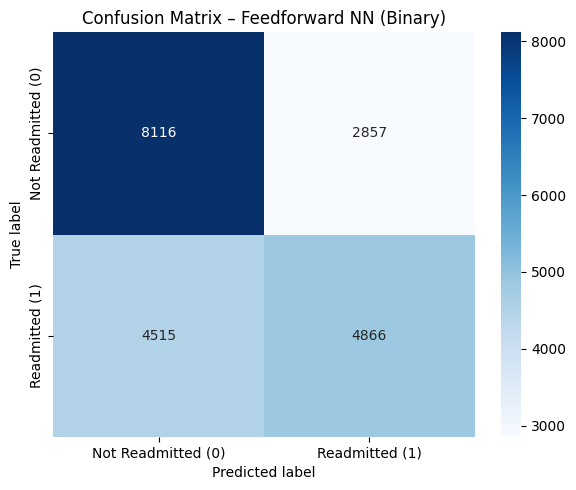

In [10]:
cm = confusion_matrix(y_test, y_pred)
labels = ["Not Readmitted (0)", "Readmitted (1)"]

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    ax=ax
)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix – Feedforward NN (Binary)")
plt.tight_layout()
plt.show()

### 8b. Loss Curve

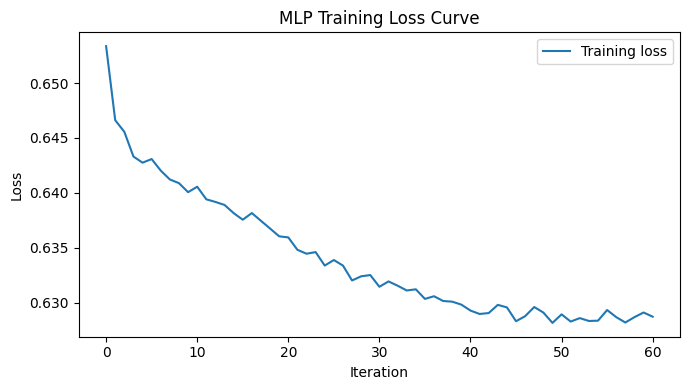

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(pipeline["model"].loss_curve_, label="Training loss")
ax.set_xlabel("Iteration")
ax.set_ylabel("Loss")
ax.set_title("MLP Training Loss Curve")
ax.legend()
plt.tight_layout()
plt.show()

### 8c. Learning Curve (Training vs. Cross-Validation score)

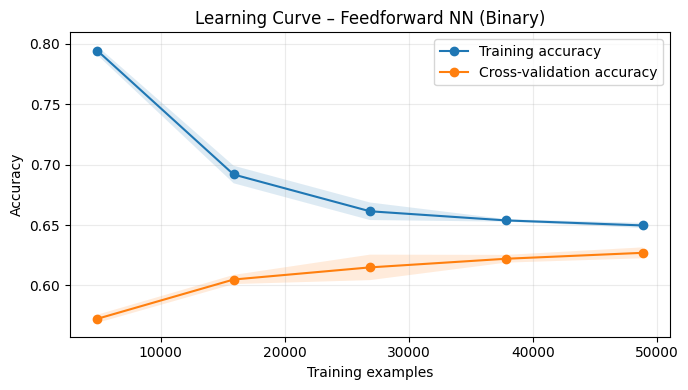

In [14]:
from sklearn.model_selection import learning_curve
cv_lc = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
train_sizes, train_scores, val_scores = learning_curve(
    estimator=pipeline,
    X=X_train,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=cv_lc,
    scoring="accuracy",
    n_jobs=1,
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(train_sizes, train_mean, marker="o", label="Training accuracy")
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)
ax.plot(train_sizes, val_mean, marker="o", label="Cross-validation accuracy")
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15)
ax.set_xlabel("Training examples")
ax.set_ylabel("Accuracy")
ax.set_title("Learning Curve – Feedforward NN (Binary)")
ax.legend()
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

## 9. Cross-Validation (5-fold)

Stratified CV on the training set for a more robust accuracy estimate.

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=1)

print(f"CV Accuracy: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")
print(f"Per-fold:    {np.round(cv_scores, 4)}")

CV Accuracy: 0.6272 +/- 0.0046
Per-fold:    [0.6277 0.6233 0.6212 0.6341 0.6297]
